# Étape 2 — Analyse des sentiments des conversations

## Notebook annoté

Ce notebook implémente un **classificateur de sentiments** sur des textes liés à la santé mentale, en suivant deux approches complémentaires :
- **Méthode supervisée** : Naive Bayes
- **Méthode non-supervisée** : K-Means

Le corpus d'entraînement utilisé est le dataset *Sentiment Analysis for Mental Health* (`Combined Data.csv`) disponible sur Kaggle.

---

## 1. Initialisation

Cette cellule importe l'ensemble des bibliothèques nécessaires au notebook :

| Bibliothèque | Rôle |
|---|---|
| `numpy`, `pandas` | Manipulation de données et tableaux numériques |
| `matplotlib`, `seaborn` | Visualisation (graphiques, camemberts) |
| `re` | Expressions régulières pour le nettoyage du texte |
| `WordCloud` | Génération de nuages de mots |
| `Counter` | Comptage de fréquences d'éléments |
| `sklearn` | Modèles ML, vectorisation, métriques d'évaluation |
| `nltk` | Traitement du langage naturel (tokenisation, stop-words) |

In [1]:
# importing libraries and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import nltk 
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

### 1.1 Chargement des données

Chargement du fichier `Combined Data.csv` dans un DataFrame pandas. Le paramètre `index_col=0` indique que la première colonne du CSV est l'index des lignes (et non une colonne de données à part entière). `df.head()` affiche les 5 premières lignes pour vérifier que le chargement s'est bien passé.

In [2]:
df=pd.read_csv("../../data/combined_data.csv",index_col=0)
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


### 1.2 Mélange des données

Le dataset est **mélangé aléatoirement** (`sample(frac=1)`) avant tout traitement. Cela évite un biais si les données sont triées par ordre (ex : toutes les lignes d'une même classe regroupées). `random_state=42` garantit la **reproductibilité** : le même ordre sera obtenu à chaque exécution. `reset_index(drop=True)` remet les indices à 0, 1, 2… après le mélange.

In [3]:
# shuffle the rows, reset the indices
df = df.sample(frac = 1 ,random_state=42).reset_index(drop = True)
df

,statement,status
0,Just as the the title says. I feel like one is...,Depression
1,a blackened sky encroached tugging behind it m...,Depression
2,"It gives you insomnia, which in turn makes you...",Depression
3,"Hello all, I'm a new submitter to this channel...",Normal
4,Thank God the CB is over for Eid,Normal
...,...,...
53038,"I used to be a very confident, cheerful person...",Depression
53039,spanx except i missed last week s lee and now ...,Normal
53040,tl dr have been abused mentally and physically...,Depression
53041,do i sell the tutorial again?,Normal


### 1.3 Distribution des classes

`value_counts()` compte le nombre d'occurrences de chaque valeur unique dans la colonne `status` (les étiquettes de sentiment). Cette étape permet de vérifier si le dataset est **équilibré** ou non — un déséquilibre important entre classes peut impacter les performances des modèles.

In [4]:
# Count the occurrences of each status
label_counts = df['status'].value_counts()
print(label_counts)

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


## 1.4 Visualisation de la distribution (camembert)

Ce graphique en camembert représente visuellement la **distribution des classes** calculée à l'étape précédente. `autopct='%1.1f%%'` affiche le pourcentage de chaque classe avec une décimale. La palette `pastel` de seaborn donne des couleurs douces et distinctes.

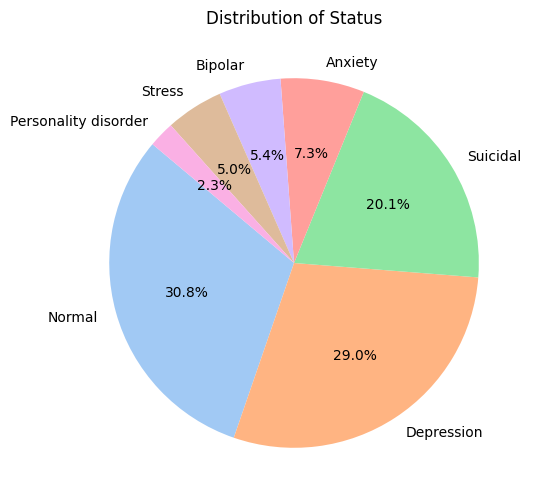

In [5]:
# Plot the pie chart
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Status');

---
## 2. Nettoyage des données
### 2.1. Détection des valeurs manquantes

`isnull().sum()` compte le nombre de valeurs `NaN` (manquantes) dans chaque colonne. C'est une étape systématique de **contrôle qualité** : des valeurs manquantes dans la colonne `statement` provoqueraient des erreurs lors du nettoyage ou de la vectorisation.

In [6]:
# Missing values
df.isnull().sum()

statement    362
status         0
dtype: int64

### 2.2 Suppression des lignes vides

`dropna(axis=0)` supprime toutes les lignes contenant au moins une valeur manquante. Le paramètre `inplace=True` modifie directement le DataFrame sans créer une copie. Cette étape fait suite à la détection précédente.

In [7]:
# Drop rows with missing values
df.dropna(axis=0, inplace = True)
df.describe()

,statement,status
count,52681,52681
unique,51073,7
top,what do you mean?,Normal
freq,22,16343


### 2.3. Détection des étiquettes conflictuelles

Certains énoncés (`statement`) peuvent apparaître plusieurs fois dans le dataset avec des étiquettes (`status`) différentes — ce qui est contradictoire pour l'apprentissage. Cette cellule identifie ces cas en comptant le nombre de statuts distincts par énoncé. Si `nunique() != 1`, l'énoncé a plusieurs labels incompatibles.

In [8]:
# Count unique statuses for each statement
duplicate_labels = df.groupby('statement')['status'].nunique()

# Filter statements with more than one unique status
conflicting_statements = duplicate_labels[duplicate_labels != 1]

# Display problematic statements
print(f"Nombre de déclarations en conflit : {len(conflicting_statements)}")

Nombre de déclarations en conflit : 18


### 2.4 Suppression des étiquettes conflictuelles

On conserve uniquement les lignes dont l'énoncé possède **un seul statut cohérent** (`nunique() == 1`). Le `transform('nunique')` propage la valeur calculée par groupe à chaque ligne individuelle, ce qui permet le filtrage. `df.shape` est affiché pour confirmer la taille du dataset après nettoyage.

In [9]:
# Remove rows with confilicting labels, only keep statements that have a single consistent status
df = df[df.groupby('statement')['status'].transform('nunique') == 1]

print(df.shape)  # Check new dataset size

(52632, 2)


### 2.5. Nettoyage du texte (`cleaner`)

Cette fonction applique plusieurs **règles de nettoyage** via des expressions régulières :

| Règle | Exemple |
|---|---|
| Suppression des mentions `@utilisateur` | `@john` → supprimé |
| Suppression des URLs | `https://...` → supprimé |
| Suppression du HTML | `<br>`, `<b>` → supprimé |
| Détection des émoticônes textuels | `:)`, `;-P` → conservés en fin |
| Mise en minuscules + suppression des non-mots | `Hello!` → `hello` |

Les émoticônes sont extraits avant la suppression des non-mots, puis réajoutés à la fin du texte nettoyé.

In [10]:
# Defining a text cleaner
import re
def cleaner(text):
    text = re.sub(r'\s*@\w+', '', text)                            # remove words starting with @ 
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)            # remove URLs 
    text = re.sub(r'<[^>]*>', '', text)                            # remove all of the HTML markup
    #text = re.sub(r'\b\w\b', '', text)                             # remove single letters, I, a, ...
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)  # find emoticons (emoji)
    text = (re.sub(r'[\W]+', ' ', text.lower()) + ' '.join(emoticons).replace('-', '')) 
    #  replace any non_word with space, lowercase words, add emojis at the end
    return text

### 2.6. Application du nettoyage

La fonction `cleaner` est appliquée à chaque ligne de la colonne `statement` via `.apply()`. `df.loc[:, 'statement']` est utilisé (plutôt que `df['statement']`) pour éviter un `SettingWithCopyWarning` de pandas lors de la modification en place. Le nombre de lignes restantes est affiché en sortie.

> **Note** : le bloc de détection de langue (`is_english`) est commenté. Il permettrait de ne conserver que les textes en anglais, mais alourdit le traitement. À réactiver si le corpus contient des textes multilingues.

In [11]:
# Cleaning the text
from langdetect import detect
from langdetect import DetectorFactory
DetectorFactory.seed = 42
df.loc[:, 'statement'] = df['statement'].apply(cleaner)
#def is_english(text):
 #   try:
  #      return detect(str(text)) == 'en'
   # except:
    #    return False  # si détection échoue on supprime la ligne
print(f"Après filtres : {df.shape[0]} lignes")
#df['statement'].apply(is_english)
#print(f"Après filtres : {df.shape[0]} lignes")
#only english text in base documents

Après filtres : 52632 lignes


### 2.7 Vérification d'un exemple nettoyé

Affiche le contenu de la ligne d'index 10 après nettoyage, pour vérifier visuellement que la fonction `cleaner` produit bien le résultat attendu (minuscules, sans ponctuation ni URL).

In [12]:
df['statement'][10]

'so i m sure all of you who live with anxiety do have your good day like the bad crippling anxiety come in wave which it doe for me when it s bad my anxiety is looking for any reason to latch it s self onto and make me believe that whatever the reason is that s what make me feel like shit when i have my good day and that thought or issue come to mind i m unfazed it s really fuckn annoying and i feel like it could make me make decision that i will for sure regret why is the brain so damn powerful and why do i have to live with this year of always feeling like shit it ha ruined my quality of life i am very grateful for my family and friend and i am grateful that i ve always had a good life but man i think of all the family trip event party anything fun ruined by my anxiety and sickness that come with it i feel for everyone that ha to go through this i m sorry guy and i hope one day we can be truly happy'

### 2.8 Séparation features / cible

On sépare le DataFrame en deux variables :
- `X` : les **features** (les énoncés textuels nettoyés, colonne `statement`)
- `y` : la **cible** (les étiquettes de sentiment, colonne `status`)

C'est la convention standard en scikit-learn avant tout découpage ou entraînement.

In [13]:
# Assigning features and target
X = df['statement']
y = df['status']

---
## 3. Entrainement du modèle
### 3.1 Découpage Train / Validation / Test

Mais alors pourquoi séparer les donnée en 3 et non 2 ?
En effet, il est courant de diviser les données en trois ensembles :
- **Ensemble d'entraînement (Train)** : utilisé pour entraîner le modèle.
- **Ensemble de validation (Validation)** : utilisé pour ajuster les hyperparamètres du modèle et éviter le surapprentissage (overfitting).
- **Ensemble de test (Test)** : utilisé pour évaluer la performance finale du modèle sur des données qu'il n'a jamais vues auparavant.
Cela permet d'avoir une évaluation plus fiable de la performance du modèle, car le test est effectué sur des données totalement indépendantes de celles utilisées pour l'entraînement et la validation.

Le paramètre `stratify=y` garantit que la **proportion de chaque classe** est identique dans les trois ensembles — indispensable en cas de déséquilibre des classes. `random_state=42` assure la reproductibilité.

In [ ]:
# First split -> 60% train, 40% temp (validation + test)
# Second split -> 20% validation, 20% test (from the 40% temp)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}")

Train : 31579 | Val : 10526 | Test : 10527


### 3.2 Vérification de la distribution des classes

On s'assure que `stratify` a bien préservé les proportions dans les 3 ensembles.

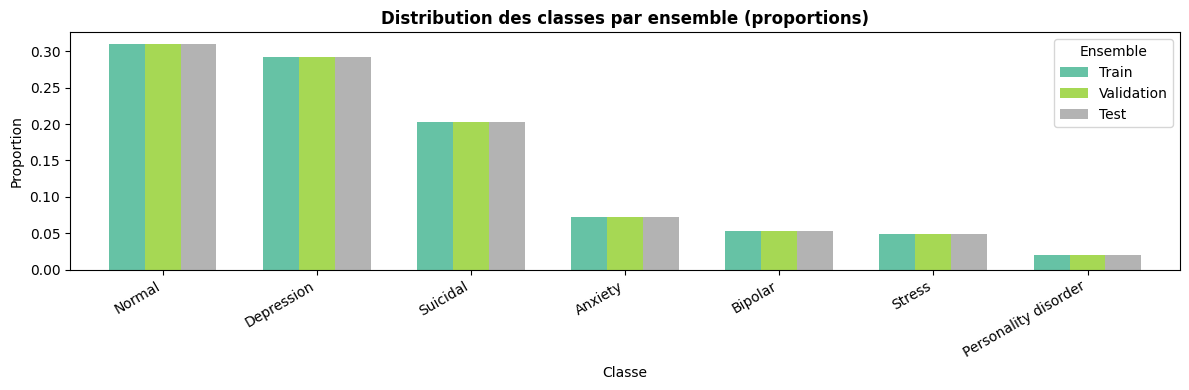

In [23]:
dist = pd.DataFrame({
    'Train'      : y_train.value_counts(normalize=True),
    'Validation' : y_val.value_counts(normalize=True),
    'Test'       : y_test.value_counts(normalize=True),
}).fillna(0)

ax = dist.plot(kind='bar', figsize=(12, 4), colormap='Set2', width=0.7)
ax.set_title('Distribution des classes par ensemble (proportions)', fontweight='bold')
ax.set_xlabel('Classe')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Ensemble')
plt.tight_layout()
plt.show()

### 3.3 Préambule tokenisation

- **Punkt** : modèle pré-entraîné de NLTK qui segmente le texte en mots tout en gérant les abréviations et la ponctuation (.,!,?).
Il gère aussi les abréviations (ex. `Dr.Smith` ne sera pas séparé en `Dr` puis `.` puis `Smith`)
- **Stop words** : mots très fréquents sans valeur sémantique (`the`, `is`, `and`…) qui sont retirés pour réduire le bruit.
- **Porter Stemmer** : algorithme qui réduit chaque mot à sa racine (`running` → `run`, `people` → `peopl`). Les formes produites ne sont pas toujours des mots réels, c'est un compromis connu.

#### 3.3.1 Fonction de tokenisation

La fonction `simple_tokenizer` applique en séquence :
1. **Tokenisation** : découpe la chaîne en liste de mots avec `word_tokenize`
2. **Filtrage des stop-words** : retire les mots sans valeur sémantique
3. **Stemming** : réduit chaque mot à sa racine avec le Porter Stemmer

L'exemple en fin de cellule (`"i.e., running faster..."`) permet de tester le comportement sur une phrase contenant une abréviation et une majuscule.

In [21]:
# Splitting text documents into tokens
import nltk 
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [20]:
# Download required NLTK data
nltk.download('punkt_tab')      # For punctuations used in word_tokenize 
nltk.download('stopwords')      # For stopword list

[nltk_data] Downloading package punkt_tab to /home/logan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/logan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
def simple_tokenizer(text):
    stop_words = set(stopwords.words('english'))    # Define stopwords (English)
    stemmer = PorterStemmer()                       # Initialize the stemmer
    tokens = word_tokenize(text)                    # Tokenize the text   
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words] # Remove stopwords   
    stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]             # Apply stemming
    return stemmed_tokens

# Example Usage
text = "i.e., running faster makes you stronger Mrs. Williams!"
print(simple_tokenizer(text))

['i.e.', ',', 'run', 'faster', 'make', 'stronger', 'mrs.', 'william', '!']


#### 3.3.2 Application de la tokenisation

La fonction `simple_tokenizer` est appliquée à chaque énoncé des ensembles train et test via `.apply()`. Chaque texte est ainsi transformé en une **liste de tokens** (racines de mots filtrés). Ces listes seront ensuite converties en vecteurs numériques par les vectoriseurs.

> **Attention**: Le temp d'exécution estimé peut aller de 1min à 2min30 !

In [25]:
# Application of tokenizer
X_train_tokens = X_train.apply(simple_tokenizer)
X_val_tokens   = X_val.apply(simple_tokenizer)
X_test_tokens  = X_test.apply(simple_tokenizer)

#### 3.3.3 Tokenisation du dataset complet

La tokenisation est également appliquée sur `X` entier (train + test confondus). Cette version `X_full` sera utilisée plus tard pour la vectorisation TF-IDF complète, notamment dans le contexte du déploiement sur le dataset principal (`train.csv`).

In [26]:
X_full=X.apply(simple_tokenizer)

#### 3.3.4. Aperçu des tokens

Affiche les 5 premières lignes tokenisées. Chaque cellule contient une liste de racines de mots. On peut y observer les effets du Porter Stemmer : `people` → `peopl`, `jealous` → `jealou`, etc. C'est le comportement attendu (voir discussion dans le notebook).

In [27]:
# View a few tokenised statements
X_train_tokens.head()

22977                                       [lemau, right]
22034    [think, peopl, see, think, worst, hate, presen...
5223     [stress, leav, anyon, ever, success, take, fml...
10113    [safe, sane, sober, check, good, support, netw...
22176    [well, coupl, month, recent, got, hit, anoth, ...
Name: statement, dtype: object

---
### 3.4. Bag-of-Words (BoW)

#### 3.4.1 Vectorisation BoW

Le **Bag-of-Words** crée une matrice où chaque ligne est un document et chaque colonne est un mot du vocabulaire. La valeur d'une cellule est le **nombre d'occurrences** du mot dans le document.

- `fit_transform` sur le train : construit le vocabulaire **et** transforme les données
- `transform` sur le test : applique le **même vocabulaire** sans le reconstruire (règle fondamentale pour éviter le data leakage)

Les tokens (listes) sont reconvertis en chaînes (`' '.join(x)`) car `CountVectorizer` attend des strings.

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

# Initializing a vectoriser
bow_vectorizer = CountVectorizer()

# Fitting to the bow-vectorizer — sur le train uniquement
X_train_bow = bow_vectorizer.fit_transform(X_train_tokens.apply(lambda x: ' '.join(x)))
X_val_bow   = bow_vectorizer.transform(X_val_tokens.apply(lambda x: ' '.join(x)))
X_test_bow  = bow_vectorizer.transform(X_test_tokens.apply(lambda x: ' '.join(x)))

#### 3.4.2. Aperçu du vocabulaire BoW

Affiche un extrait du vocabulaire appris par le `CountVectorizer` (tokens de rang 2000 à 2080). Permet de vérifier que les termes stockés sont bien des racines issues du stemming, et non des mots bruts.

In [29]:
# Show some of the vocabulary words
bow_vectorizer.get_feature_names_out()[2000:2080]  

array(['alamin', 'alan', 'alanin', 'alarm', 'alarmingli', 'alaska',
       'albanian', 'albeit', 'albert', 'alberta', 'albertson', 'album',
       'albumin', 'alc', 'alcahol', 'alcançar', 'alcapa', 'alchemist',
       'alchi', 'alchoh', 'alchohol', 'alchool', 'alco', 'alcohol',
       'alcoholi', 'alcol', 'alcoohol', 'alcool', 'ale', 'aleay', 'alec',
       'alejandralei', 'alement', 'alergi', 'alert', 'alessandrod',
       'alesso', 'alev', 'alevel', 'alex', 'alexa', 'alexandernl',
       'alexfost', 'alexlobaloba', 'alexrussin', 'alfredo', 'alg',
       'algebra', 'algn', 'algo', 'algonquin', 'algorithm', 'alguna',
       'alguno', 'alguém', 'alhaji', 'alhamdulilah', 'alhamdulillaaah',
       'alhamdulillah', 'alhasani', 'alhogol', 'ali', 'alia', 'alic',
       'aliceeu', 'aliceverheij', 'alielayu', 'alien', 'align', 'alik',
       'alimoni', 'alimwomba', 'alissa', 'alist', 'alittl', 'aliv',
       'alivei', 'aliveim', 'alivesomewher', 'alivesorri'], dtype=object)

#### 3.4.3 Dimensions de la matrice BoW

`X_train_bow.shape` retourne `(n_documents, n_features)` — le nombre de documents d'entraînement et la taille du vocabulaire. La matrice est **creuse** (sparse) : la plupart des cellules valent 0 car chaque document n'utilise qu'une infime fraction du vocabulaire total.

In [30]:
# View the dimensions of the BoW matrix and a small portion of its data
print(X_train_bow.shape)  # (num_samples: documents, num_features: unique tokens)
print(X_train_bow[:5])    # Shows first 5 rows (sparse format: only non-zero elements)

(31579, 31180)
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 110 stored elements and shape (5, 31180)>
  Coords	Values
  (0, 16090)	1
  (0, 23209)	1
  (1, 27344)	2
  (1, 20699)	1
  (1, 24119)	1
  (1, 30466)	1
  (1, 12582)	1
  (1, 21596)	1
  (1, 9428)	1
  (1, 13675)	1
  (1, 9870)	1
  (1, 16953)	1
  (1, 29051)	1
  (2, 26095)	2
  (2, 16035)	3
  (2, 2620)	1
  (2, 9716)	1
  (2, 26256)	1
  (2, 26764)	1
  (2, 10756)	1
  (2, 21735)	1
  (2, 16272)	1
  (2, 23089)	1
  (2, 21637)	1
  (2, 9269)	1
  :	:
  (4, 27881)	1
  (4, 29960)	1
  (4, 6737)	1
  (4, 18137)	1
  (4, 22576)	1
  (4, 11922)	1
  (4, 13055)	1
  (4, 2496)	1
  (4, 29833)	1
  (4, 7675)	1
  (4, 10563)	1
  (4, 1411)	1
  (4, 20787)	1
  (4, 13532)	2
  (4, 9098)	1
  (4, 9343)	1
  (4, 5252)	2
  (4, 9391)	1
  (4, 27620)	1
  (4, 12826)	1
  (4, 18256)	1
  (4, 3628)	1
  (4, 18831)	1
  (4, 22510)	1
  (4, 26140)	1


### 3.5 TF-IDF
#### 3.5.1 Vectorisation TF-IDF

Le **TF-IDF** (Term Frequency - Inverse Document Frequency) améliore le BoW en pondérant les mots : un mot fréquent dans un document mais rare dans le corpus global reçoit un score élevé, et inversement.

Paramètres utilisés :
- `ngram_range=(1, 2)` : prend en compte les **unigrammes** (mots seuls) et les **bigrammes** (paires de mots consécutifs)
- `max_df=0.8` : ignore les mots présents dans plus de 80% des documents (trop communs)
- `min_df=5` : ignore les mots présents dans moins de 5 documents (trop rares)

Même logique que BoW : `fit_transform` sur train uniquement, `transform` sur test et full.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Define TfidfVectorizer with n-gram range
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.8, min_df=5)

# Apply TfidfVectorizer — fit sur le train uniquement
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_tokens.apply(lambda x: ' '.join(x)))
X_val_tfidf   = tfidf_vectorizer.transform(X_val_tokens.apply(lambda x: ' '.join(x)))
X_test_tfidf  = tfidf_vectorizer.transform(X_test_tokens.apply(lambda x: ' '.join(x)))
x_full_tfidf  = tfidf_vectorizer.transform(X_full.apply(lambda x: ' '.join(x)))

#### 3.5.2 Aperçu des features TF-IDF

Affiche un extrait des features apprises par le `TfidfVectorizer`. On peut y observer des **bigrammes** (ex: `feel anxious`, `mental health`) en plus des unigrammes, ce qui enrichit la représentation sémantique par rapport au BoW simple.

In [34]:
# View Feature Names (Words or N-grams)
print(tfidf_vectorizer.get_feature_names_out()[20100:20150])

['goal like' 'goal motiv' 'goal plan' 'goal seem' 'goal set' 'goal tri'
 'goal want' 'goal weight' 'god' 'god alway' 'god aw' 'god bless'
 'god creat' 'god damn' 'god exist' 'god feel' 'god forbid' 'god forgiv'
 'god forsaken' 'god fuck' 'god get' 'god given' 'god go' 'god god'
 'god hate' 'god help' 'god hope' 'god kill' 'god know' 'god let'
 'god live' 'god love' 'god make' 'god pleas' 'god punish' 'god realli'
 'god sake' 'god someth' 'god still' 'god take' 'god tell' 'god test'
 'god think' 'god tri' 'god want' 'god wish' 'god would' 'goddamn' 'goe'
 'goe away']


#### 3.5.3 Dimensions de la matrice TF-IDF

Vérifie la forme de la matrice TF-IDF et affiche les scores non-nuls des 3 premiers documents. Les valeurs sont des **flottants entre 0 et 1** (contrairement au BoW qui sont des entiers), car TF-IDF normalise les fréquences.

In [35]:
# See the dimensions of the BoW matrix and a small portion of its data
print(X_train_tfidf.shape) # (num_samples: documents, num_features: unique n-grams)
print(X_train_tfidf[:3])   # Shows nonzero TF-IDF scores in the first 3 documents

(31579, 56067)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 38 stored elements and shape (3, 56067)>
  Coords	Values
  (0, 40211)	1.0
  (1, 48261)	0.20868377649866512
  (1, 36143)	0.10948612641115503
  (1, 41579)	0.12591102104213575
  (1, 54877)	0.18582410832909743
  (1, 21809)	0.13724233450912454
  (1, 37745)	0.2905804861431099
  (1, 13657)	0.19626631333670994
  (1, 23905)	0.17832970452564795
  (1, 15081)	0.1776616948619775
  (1, 30144)	0.10762765337893847
  (1, 51463)	0.21556316543361637
  (1, 48520)	0.28031202631998314
  (1, 36413)	0.2816972103052587
  (1, 41775)	0.33977362819199974
  (1, 48657)	0.32801922227503
  (1, 15107)	0.3700884567824035
  (1, 30379)	0.33605661100387485
  (2, 45487)	0.22261162699359427
  (2, 26778)	0.32388603023517093
  (2, 3120)	0.08478777652819298
  (2, 14311)	0.09614251300906855
  (2, 45980)	0.14618361969506102
  (2, 46753)	0.0832005265513883
  (2, 17364)	0.23403379913343939
  (2, 38073)	0.1537127488066804
  (2, 27675)	0.05659581631374521
 

---
# **Fin de la partie commune ICI**

---

# 🔀 À partir d'ici : travail individuel

La partie commune est terminée. Vous disposez maintenant des variables suivantes, prêtes à l'emploi :

| Variable | Description |
|---|---|
| `X_train_bow`, `X_val_bow`, `X_test_bow` | Matrices Bag-of-Words (train / val / test) |
| `X_train_tfidf`, `X_val_tfidf`, `X_test_tfidf` | Matrices TF-IDF (train / val / test) |
| `X_full`, `x_full_tfidf` | Dataset complet tokenisé / vectorisé (pour le déploiement final) |
| `y_train`, `y_val`, `y_test` | Étiquettes de sentiment correspondantes |

Le notebook se divise maintenant en **deux parties indépendantes** selon votre groupe :

- 🟦 **Partie A — Méthode supervisée (Naive Bayes)** → Groupe : Diogo, Victor, Ulysse, Logan
- 🟩 **Partie B — Méthode non-supervisée (K-Means)** → Groupe : Emin

Travaillez uniquement la partie qui vous correspond. Les deux parties aboutissent à une **annotation automatique de `train.csv`** qui sera transmise au Groupe 2.


---

# 🟦 Partie A — Méthode supervisée : Naive Bayes

> **Objectif** : Entraîner un classifieur Naive Bayes pour prédire le sentiment d'un texte lié à la santé mentale, à partir des représentations vectorielles BoW et TF-IDF construites en partie commune.

Cette partie suit le pipeline suivant :

```
Tuning alpha (validation) → Entraînement → Prédictions → Évaluation → Déploiement sur train.csv
```


## A.1 — Tuning de l'hyperparamètre `alpha`

Le Naive Bayes multinomial possède un hyperparamètre `alpha` (lissage de Laplace). Avant d'entraîner le modèle final, on sélectionne la meilleure valeur d'`alpha` **sur l'ensemble de validation** (et non sur le test, pour éviter le data leakage).

**Ce que vous devez faire :**

1. Définir une liste de valeurs candidates pour `alpha`, par exemple : `[0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]`
2. Pour chaque valeur d'`alpha` :
   - Instancier un `MultinomialNB(alpha=alpha)` depuis `sklearn.naive_bayes`
   - L'entraîner sur `X_train_bow` / `y_train` (puis idem avec TF-IDF)
   - Prédire sur `X_val_bow` / `X_val_tfidf`
   - Calculer l'accuracy sur la validation avec `accuracy_score`
3. Stocker les résultats dans un DataFrame et identifier le meilleur `alpha` pour BoW et pour TF-IDF séparément
4. Sauvegarder ces valeurs dans `best_alpha_bow` et `best_alpha_tfidf`

> 💡 **Pourquoi la validation et pas le test ?** Le test doit rester "invisible" jusqu'à l'évaluation finale. Le réserver garantit une mesure honnête des performances réelles du modèle.


In [ ]:
# A.1 — Votre code ici


### A.1.1 — Courbe de validation

**Ce que vous devez faire :**

Tracer une courbe (avec `matplotlib`) montrant l'accuracy de validation en fonction d'`alpha` (en abscisse log) pour les deux variantes BoW et TF-IDF sur le même graphique. Ajouter une ligne verticale pointillée indiquant le meilleur `alpha` retenu pour chacune.

> 💡 Utilisez `ax.semilogx(...)` pour une abscisse en échelle logarithmique.


In [ ]:
# A.1.1 — Votre code ici


## A.2 — Entraînement des modèles Naive Bayes

**Ce que vous devez faire :**

En utilisant les meilleurs alphas trouvés à l'étape précédente (`best_alpha_bow`, `best_alpha_tfidf`) :

1. Instancier deux modèles `MultinomialNB` :
   - `nb_model_bow` avec `alpha=best_alpha_bow`
   - `nb_model_tfidf` avec `alpha=best_alpha_tfidf`
2. Entraîner chaque modèle sur l'ensemble d'entraînement correspondant (`.fit(X_train_..., y_train)`)

> ⚠️ On entraîne **uniquement sur `X_train`**, jamais sur val ou test.


In [ ]:
# A.2 — Votre code ici


## A.3 — Prédictions sur le test

**Ce que vous devez faire :**

Générer les prédictions des deux modèles sur `X_test_bow` et `X_test_tfidf` avec `.predict(...)`.

Stocker les résultats dans :
- `nb_predictions_bow`
- `nb_predictions_tfidf`


In [ ]:
# A.3 — Votre code ici


## A.4 — Évaluation quantitative

**Ce que vous devez faire :**

Pour chaque variante (BoW et TF-IDF), calculer et afficher les métriques suivantes :

| Métrique | Fonction sklearn | Ce qu'elle mesure |
|---|---|---|
| **Accuracy** | `accuracy_score` | Proportion de prédictions correctes |
| **MSE** | `mean_squared_error` | Erreur quadratique moyenne (sur labels encodés) |
| **R²** | `r2_score` | Coefficient de détermination |
| **Classification report** | `classification_report` | Précision, rappel, F1-score par classe |
| **Matrice de confusion** | `ConfusionMatrixDisplay` | Visualisation des erreurs par classe |

> 💡 Pour MSE et R², les labels textuels doivent d'abord être encodés en entiers avec `LabelEncoder` de `sklearn.preprocessing`. Faites un `.fit` sur `y_train` uniquement, puis `.transform` sur `y_test` et les prédictions.

> 💡 Pensez à tracer la matrice de confusion avec `ConfusionMatrixDisplay.from_predictions(...)` et à faire pivoter les étiquettes en abscisse pour la lisibilité (`plt.xticks(rotation=45, ha='right')`).


In [ ]:
# A.4 — Votre code ici


## A.5 — Déploiement sur le dataset principal (`train.csv`)

C'est l'étape finale de la partie supervisée. Le meilleur modèle (BoW ou TF-IDF, selon vos résultats) est utilisé pour **annoter automatiquement** le dataset principal `train.csv`, qui sera transmis au Groupe 2.

**Ce que vous devez faire :**

1. Identifier lequel de `nb_model_bow` ou `nb_model_tfidf` obtient la meilleure accuracy sur le test
2. Charger `train.csv` (disponible dans `../../data/train.csv`) dans un DataFrame `df_main`
3. Appliquer la même chaîne de prétraitement que sur `combined_data.csv` :
   - Nettoyage (`cleaner`)
   - Tokenisation (`simple_tokenizer`)
   - Vectorisation avec le **vectoriseur déjà fitté** sur le train (`bow_vectorizer.transform(...)` ou `tfidf_vectorizer.transform(...)`) — **ne pas refaire de `.fit`**
4. Générer les prédictions avec le meilleur modèle et les stocker dans une colonne `predicted_sentiment`
5. Afficher les 10 premières lignes avec la colonne de prédiction
6. Sauvegarder le DataFrame annoté dans un fichier CSV : `train_with_sentiments.csv`

> ⚠️ Variable nommée `x_full_tfidf` (disponible depuis la partie commune) si vous souhaitez éviter de recalculer la vectorisation sur tout le corpus.

> 💡 La distribution des sentiments prédits doit ressembler approximativement à celle observée sur `combined_data.csv`. Si une classe domine massivement, cela peut indiquer un problème dans le pipeline.


In [ ]:
# A.5 — Votre code ici


---

# 🟩 Partie B — Méthode non-supervisée : K-Means

> **Objectif** : Regrouper automatiquement les textes en clusters sans utiliser les étiquettes, puis comparer ces clusters aux catégories réelles, évaluer la qualité du regroupement, et annoter `train.csv` avec le meilleur modèle.

Cette partie suit le pipeline suivant :

```
Réduction dimensionnelle (SVD) → Sélection de k (validation) → Entraînement → Mapping cluster→label → Évaluation → Déploiement
```

> 💡 K-Means est dit "non-supervisé" car il ne voit jamais les étiquettes pendant l'entraînement. Les étiquettes sont uniquement utilisées **après** pour évaluer la qualité des clusters obtenus.


## B.1 — Réduction dimensionnelle et normalisation

Les matrices TF-IDF et BoW sont de très grande dimension (des dizaines de milliers de colonnes). K-Means fonctionne mieux dans un espace réduit.

**Ce que vous devez faire :**

1. Appliquer une **réduction dimensionnelle** avec `TruncatedSVD` (de `sklearn.decomposition`) :
   - Choisir `n_components=100` (ou moins si la matrice est plus petite)
   - **Important** : faire le `.fit_transform` sur `X_train_tfidf` uniquement, puis `.transform` sur `X_val_tfidf` et `X_test_tfidf`
2. **Normaliser** les matrices résultantes avec `normalize(..., norm='l2')` (de `sklearn.preprocessing`) pour que K-Means utilise une distance cosinus implicite

> 💡 **Pourquoi SVD ?** TF-IDF produit des matrices creuses (sparse) de très haute dimension. SVD compresse l'information en conservant les directions de variance maximale — similaire à une PCA, mais compatible avec les matrices creuses.

> ⚠️ Ne jamais `.fit` le SVD sur la validation ou le test. Appliquer uniquement `.transform`.


In [ ]:
# B.1 — Votre code ici


## B.2 — Sélection du nombre de clusters `k`

K-Means nécessite de choisir `k` (le nombre de clusters) à l'avance. On utilise deux critères complémentaires pour guider ce choix **sur l'ensemble de validation** :

**Ce que vous devez faire :**

1. Tester des valeurs de `k` allant de 2 à 15 (ou jusqu'au nombre de classes réelles)
2. Pour chaque `k` :
   - Entraîner un `MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, n_init=10)` sur les données d'entraînement réduites
   - Prédire les clusters sur la **validation** avec `.predict(...)`
   - Calculer :
     - **WCSS** (inertie, `.inertia_`) — méthode du coude : on cherche le "coude" dans la courbe
     - **Score silhouette cosinus** avec `silhouette_score(..., metric='cosine')` — on cherche le maximum
3. Tracer deux graphiques côte à côte : WCSS en fonction de k, et silhouette en fonction de k
4. Identifier le `k` retenu (`best_k`) : celui qui maximise la silhouette sur la validation
5. Appliquer un plancher : `best_k = max(best_k, nombre_de_classes_réelles)` pour garantir qu'il y a au moins un cluster par classe possible

> 💡 `silhouette_score` peut être lent sur grands datasets — utilisez `sample_size=2000` pour le limiter.

> 💡 `MiniBatchKMeans` est une version plus rapide de K-Means, adaptée aux grands datasets. Son comportement est identique mais il traite les données par mini-lots.


In [ ]:
# B.2 — Votre code ici


## B.3 — Entraînement final et mapping cluster → label

**Ce que vous devez faire :**

1. Entraîner un `MiniBatchKMeans` final avec le `best_k` retenu, **sur les données d'entraînement uniquement**
2. Récupérer les identifiants de clusters prédits sur le train avec `.fit_predict(...)`
3. Construire un dictionnaire `cluster_to_label` qui associe chaque cluster à une étiquette de sentiment, par **vote majoritaire** :
   - Pour chaque cluster `c`, regarder les étiquettes réelles (`y_train`) de tous les points du cluster
   - Attribuer à `c` l'étiquette la plus fréquente parmi ces points
   - Si deux clusters voudraient la même étiquette, utiliser une stratégie gloutonne : attribuer l'étiquette au cluster de plus haute pureté, puis passer à la deuxième étiquette pour l'autre

> 💡 La **pureté d'un cluster** = proportion du label majoritaire dans ce cluster. Un cluster de pureté 1.0 est parfaitement homogène.

> 💡 Affichez le mapping final (cluster → label → pureté) pour interpréter vos résultats.


In [ ]:
# B.3 — Votre code ici


## B.4 — Évaluation quantitative

La méthode non-supervisée n'a pas accès aux étiquettes pendant l'entraînement, mais on peut néanmoins évaluer la qualité des clusters **après coup** en les comparant aux vraies étiquettes.

**Ce que vous devez faire :**

1. Prédire les clusters sur `X_test` réduit, puis convertir en étiquettes via `cluster_to_label`
2. Calculer les métriques suivantes :

| Métrique | Description | Interprétation |
|---|---|---|
| **Accuracy** | Proportion de bonne classification (après mapping) | Entre 0 et 1, plus c'est élevé mieux c'est |
| **Matrice de confusion** | Visualisation des erreurs | Diagonale dominante = bon clustering |
| **Purity** | Proportion de documents bien assignés au sens du vote majoritaire | Entre 0 et 1 |
| **ARI** (Adjusted Rand Index) | Mesure l'accord entre clusters et vraies étiquettes, corrigée du hasard | 0 = hasard, 1 = parfait, peut être négatif |

> 💡 **Purity** : pour chaque vrai label, on trouve le cluster qui le contient le plus, puis on somme ces maximums et on divise par le total.

> 💡 **ARI** s'obtient avec `adjusted_rand_score(y_true, y_pred)` de `sklearn.metrics`. Il est plus fiable que la purity car il est insensible aux classes déséquilibrées.

3. Interpréter vos résultats : les clusters correspondent-ils aux catégories réelles ? Quelles classes sont bien séparées ? Lesquelles sont confondues ?


In [ ]:
# B.4 — Votre code ici


## B.5 — Comparaison avec la méthode supervisée

Une fois les deux méthodes évaluées (supervisée par le Groupe 1, non-supervisée ici), il faut décider laquelle utiliser pour l'annotation finale.

**Ce que vous devez faire :**

Rédiger une courte analyse (dans cette cellule markdown ou dans une cellule code avec des `print`) comparant :

- L'accuracy respective des deux méthodes sur le test
- La nature des erreurs observées (quelles classes sont mal prédites dans chaque cas ?)
- Les avantages et limites de chaque approche dans ce contexte

> 💡 **Comment comparer supervisé et non-supervisé ?** C'est une vraie question méthodologique. La comparaison directe par accuracy est possible ici car le mapping cluster→label permet d'obtenir des prédictions dans le même espace. Cependant, le non-supervisé ne "voit" pas les labels pendant l'entraînement, donc une accuracy inférieure est attendue — ce n'est pas forcément un défaut, mais plutôt la contrepartie de l'absence d'annotation.

Conclure en indiquant quel modèle sera utilisé pour l'annotation de `train.csv`.


In [ ]:
# B.5 — Votre analyse ici (commentaires Python ou cellule markdown)


## B.6 — Déploiement sur le dataset principal (`train.csv`)

**Ce que vous devez faire :**

1. Charger `train.csv` dans un DataFrame `df_main`
2. Appliquer la même chaîne de prétraitement :
   - Nettoyage (`cleaner`)
   - Tokenisation (`simple_tokenizer`)
   - Vectorisation avec le **vectoriseur déjà fitté** (`.transform` uniquement, pas de nouveau `.fit`)
   - Réduction SVD avec le **SVD déjà fitté** (`.transform` uniquement)
   - Normalisation L2
3. Prédire les clusters avec le modèle K-Means final, puis convertir en étiquettes via `cluster_to_label`
4. Ajouter une colonne `predicted_sentiment` au DataFrame
5. Afficher les 10 premières lignes annotées
6. Sauvegarder le DataFrame annoté dans `train_with_sentiments_kmeans.csv`

> ⚠️ Toutes les transformations (SVD, vectoriseur) doivent avoir été fittées **uniquement sur le train de `combined_data.csv`**. Ne pas refaire de fit sur `train.csv`.


In [ ]:
# B.6 — Votre code ici


---

# 📋 Récapitulatif et transmission au Groupe 2

Une fois les deux parties terminées, mettre en commun les résultats :

| Étape | Groupe supervisé | Groupe non-supervisé |
|---|---|---|
| Meilleure accuracy (test) | ? | ? |
| Modèle retenu | Naive Bayes BoW ou TF-IDF | K-Means TF-IDF ou BoW |
| Fichier produit | `train_with_sentiments.csv` | `train_with_sentiments_kmeans.csv` |

**Décision finale** : le modèle avec la meilleure accuracy (ou justifiée par d'autres critères) est sélectionné pour fournir les annotations au Groupe 2.

Le fichier `train_with_sentiments.csv` (ou `_kmeans`) contenant la colonne `predicted_sentiment` est transmis au Groupe 2 pour le filtrage par sentiments dans le système Q&A.
